In [3]:
%%capture
!pip install --upgrade --force-reinstall protobuf==6.31.1

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras.callbacks import TensorBoard

datos, metadatos = tfds.load(
    'cats_vs_dogs',
    as_supervised=True,
    with_info=True
)

/usr/local/lib/python3.12/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next r

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.RKEK5H_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [4]:
datos_entrenamiento = []
tam_imagen = 100

#Redimensionar las imagenes (tamaño y color)
for i, (imagen, etiqueta) in enumerate(datos['train']):
  imagen = cv2.resize(imagen.numpy(), (tam_imagen, tam_imagen))
  imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
  imagen = imagen.reshape(tam_imagen, tam_imagen, 1)
  datos_entrenamiento.append([imagen, etiqueta])

In [5]:
len(datos_entrenamiento)

23262

In [6]:
#Separar las variables (entradas) y (etiquetas)

X = []
y = []

for imagen, etiqueta in datos_entrenamiento:
  X.append(imagen)
  y.append(etiqueta)

#Normalizar los datos de X (imagenes)
X = np.array(X).astype(float) / 255
y = np.array(y)

In [7]:
X.shape

(23262, 100, 100, 1)

In [8]:
#Creación de modelos
modeloDenso = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(100, 100, 1)),
  tf.keras.layers.Dense(150, activation='relu'),
  tf.keras.layers.Dense(150, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

modeloCNN = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 1)),
  tf.keras.layers.MaxPooling2D(2, 2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2, 2),
  tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2, 2),

  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(100, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

modeloCNN2 = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 1)),
  tf.keras.layers.MaxPooling2D(2, 2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2, 2),
  tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2, 2),

  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(250, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
modeloDenso.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

modeloCNN.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

modeloCNN2.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

In [10]:
tensorboardDenso = TensorBoard(log_dir='logs/denso')
modeloDenso.fit(X, y, batch_size=32,
                validation_split=0.15,
                epochs=100,
                callbacks=[tensorboardDenso])

Epoch 1/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5379 - loss: 0.7174 - val_accuracy: 0.5756 - val_loss: 0.6853
Epoch 2/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5734 - loss: 0.6758 - val_accuracy: 0.5957 - val_loss: 0.6653
Epoch 3/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5870 - loss: 0.6695 - val_accuracy: 0.5989 - val_loss: 0.6749
Epoch 4/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5986 - loss: 0.6643 - val_accuracy: 0.5963 - val_loss: 0.6639
Epoch 5/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6029 - loss: 0.6619 - val_accuracy: 0.6011 - val_loss: 0.6653
Epoch 6/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6039 - loss: 0.6603 - val_accuracy: 0.6077 - val_loss: 0.6593
Epoch 7/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6004 - loss: 0.6628 - val_accuracy: 0.5911 - val_loss: 0.6686
Epoch 8/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6032 - loss: 0.6594 - val_accu

In [11]:
tensorboardCNN = TensorBoard(log_dir='logs/cnn')
modeloCNN.fit(X, y, batch_size=32,
                validation_split=0.15,
                epochs=100,
                callbacks=[tensorboardCNN])

Epoch 1/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.5790 - loss: 0.6682 - val_accuracy: 0.6387 - val_loss: 0.6329
Epoch 2/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7224 - loss: 0.5435 - val_accuracy: 0.7582 - val_loss: 0.5019
Epoch 3/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7932 - loss: 0.4461 - val_accuracy: 0.7963 - val_loss: 0.4479
Epoch 4/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8235 - loss: 0.3905 - val_accuracy: 0.7759 - val_loss: 0.4577
Epoch 5/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8530 - loss: 0.3345 - val_accuracy: 0.8341 - val_loss: 0.3805
Epoch 6/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8776 - loss: 0.2820 - val_accuracy: 0.8358 - val_loss: 0.4011
Epoch 7/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9026 - loss: 0.2293 - val_accuracy: 0.8330 - val_loss: 0.4012
Epoch 8/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9287 - loss: 0.1784 

In [12]:
tensorboardCNN2 = TensorBoard(log_dir='logs/cnn2')
modeloCNN2.fit(X, y, batch_size=32,
                validation_split=0.15,
                epochs=100,
                callbacks=[tensorboardCNN2])

Epoch 1/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.6163 - loss: 0.6424 - val_accuracy: 0.7152 - val_loss: 0.5507
Epoch 2/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7546 - loss: 0.5004 - val_accuracy: 0.7415 - val_loss: 0.5295
Epoch 3/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7964 - loss: 0.4388 - val_accuracy: 0.8135 - val_loss: 0.4134
Epoch 4/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8272 - loss: 0.3846 - val_accuracy: 0.8155 - val_loss: 0.4043
Epoch 5/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8460 - loss: 0.3468 - val_accuracy: 0.8292 - val_loss: 0.3832
Epoch 6/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8657 - loss: 0.3114 - val_accuracy: 0.8458 - val_loss: 0.3513
Epoch 7/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8831 - loss: 0.2700 - val_accuracy: 0.8530 - val_loss: 0.3419
Epoch 8/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9009 - loss: 0.2379 -

In [13]:
#Cargar la extension de tensorboard de colab
%load_ext tensorboard

In [14]:
#Ejecutar tensorboard e indicarle que lea la carpeta "logs"
%tensorboard --logdir logs

<IPython.core.display.Javascript object>

In [15]:
#Realizar el aumento de datos con varias transformaciones
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=15,
    zoom_range=[0.7, 1.4],
    horizontal_flip=True,
    vertical_flip=True
)

datagen.fit(X)

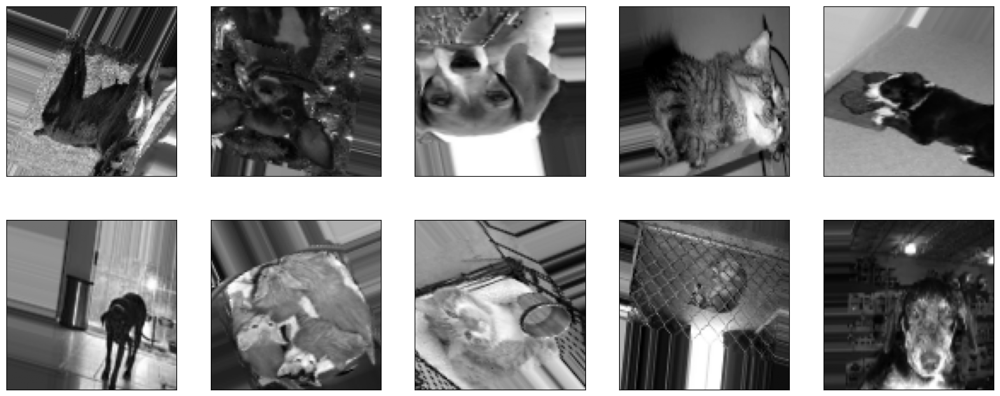

In [16]:
plt.figure(figsize=(20,8))

for imagen, etiqueta in datagen.flow(X, y, batch_size=10, shuffle=False):
  for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(imagen[i].reshape(100, 100), cmap="gray")
  break

In [17]:
modeloCNN_AD = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 1)),
  tf.keras.layers.MaxPooling2D(2, 2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2, 2),
  tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2, 2),

  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(100, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
modeloCNN_AD.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

In [19]:
X_entrenamiento = X[:19700]
X_validacion = X[19700:]

y_entrenamiento = y[:19700]
y_validacion = y[19700:]

In [20]:
#Usar la funcion flow del generador para crear un iterador que podamos enviar como entrenamiento a la funcion FIT del modelo
data_gen_entrenamiento = datagen.flow(X_entrenamiento, y_entrenamiento, batch_size=32)

In [21]:
tensorboardCNN_AD = TensorBoard(log_dir='logs-new/cnn_AD')

modeloCNN_AD.fit(
    data_gen_entrenamiento,
    epochs=150, batch_size=32,
    validation_data=(X_validacion, y_validacion),
    steps_per_epoch=int(np.ceil(len(X_entrenamiento) / float(32))),
    validation_steps=int(np.ceil(len(X_validacion) / float(32))),
    callbacks=[tensorboardCNN_AD]
)

Epoch 1/150
616/616 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step - accuracy: 0.5485 - loss: 0.6842 - val_accuracy: 0.5870 - val_loss: 0.6683
Epoch 2/150
616/616 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.5915 - loss: 0.6693 - val_accuracy: 0.6210 - val_loss: 0.6549
Epoch 3/150
616/616 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.6174 - loss: 0.6542 - val_accuracy: 0.6303 - val_loss: 0.6462
Epoch 4/150
616/616 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.6368 - loss: 0.6415 - val_accuracy: 0.6421 - val_loss: 0.6254
Epoch 5/150
616/616 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.6478 - loss: 0.6299 - val_accuracy: 0.6713 - val_loss: 0.6018
Epoch 6/150
616/616 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.6637 - loss: 0.6166 - val_accuracy: 0.6648 - val_loss: 0.6015
Epoch 7/150
616/616 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.6766 - loss: 0.6039 - val_accuracy: 0.7150 - val_loss: 0.5565
Epoch 8/150
616/616 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.6818 - loss: 0

In [22]:
#Ejecutar tensorboard e indicarle que lea la carpeta "logs-new"
%tensorboard --logdir logs-new

<IPython.core.display.Javascript object>

In [30]:
# Exportar como SavedModel (formato nativo de TF, no depende de Keras 3 para nada)
modeloCNN_AD.export("saved_model")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 1), dtype=tf.float32, name='keras_tensor_26')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139420367423440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420367424208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420367424016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420367423056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420367424784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420367424400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420367425168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420367424976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420367425552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420367425360: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [31]:
# Instalar/asegurar tensorflowjs
!pip install tensorflowjs -q

In [32]:
# Convertir el SavedModel a formato GraphModel para TensorFlow.js
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --signature_name=serving_default \
    --saved_model_tags=serve \
    saved_model \
    carpeta_salida_graph

2026-08-03 10:29:24.799348: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785752964.820633   43414 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785752964.827597   43414 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785752964.844513   43414 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785752964.844556   43414 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785752964.844561   43414 computation_placer.cc:177] computation placer alr